# Comparison of Monte Carlo simulations against Black-Scholes model
The performance of Monte Carlo simulations at estimating the theoretical prices from the Black-Scholes model will be assessed in this notebook on these areas:
- Comparison of premium values
- Variance reduction of Monte Carlo simulations
- Comparison of Greeks

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
# Set to None for pseudo-random results, 42 for reproducing the results in README.md
rng_seed = 42

## Geometric Brownian motion of prices

Black-Scholes model is the simplest option pricing model. It assumes that asset prices follow geometric Brownian motion. The time-evolution of the price $S(t)$ of an asset that is governed by geometric Brownian motion can be described by the stochastic differential equation,
$$dS(t)=\mu S_t dt + \sigma S_t dW(t) \tag{1}.$$
with $\mu$ and $\sigma$ as the drift and volatility of the asset respectively. $W(t)$ is the price according to the standard Wiener process (also known as standard Brownian motion) at time $t$. Using Itô's lemma, we obtain the solution
$$S(t)=S(0) \exp[(\mu-\frac{1}{2}\sigma^2)t+\sigma W(t)] \tag{2}.$$
The recursion relation of a standard Wiener trajectory across $n$ steps for all $i \in \{0, 1, ..., n\}$ is given by Eq. 3.2 from Glasserman (2003) [1],
$$ W(t_{i+1})=W(t_i)+\sqrt{t_{i+1}-t_i} Z_{i+1} \tag{3}, $$
where $Z_{i}$ is a sample randomly drawn from a standard normal distribution $\mathcal{N}(0,1)$. Thus the recursive relation of the asset price is
$$ \frac{S(t_{i+1})}{S(t_i)}=\exp[(\mu-\frac{1}{2}\sigma^2)(t_{i-1}-t_i)+\sigma\sqrt{t_{i+1}-t_i}Z_{i+1}]. \tag{4} $$

In [9]:
def generate_gbm(S0: float, mu: float, sigma: float, T: float, n_steps, n_paths, seed=None):
    '''
    Generates a matrix of geometric brownian motion trajectories, with n_steps 
    rows and n_paths columns. 

    Parameters
    ----------
    S0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of simulated paths to be generated
    seed: Random number generator seed, can be set for reproducibility
    '''

    dt = T / n_steps
    rng = np.random.default_rng(seed)

    # Draw samples from standard normal distribution
    Z = rng.normal(0, 1, size=(n_steps, n_paths))

    # Multiplication factor per step
    step_factors = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    # Insert a row of 1s at the top to represent the t=0 state
    step_factors = np.vstack([np.ones((1, n_paths)), step_factors])

    # Cumulative product of asset prices
    paths = S0 * np.cumprod(step_factors, axis=0)

    return paths

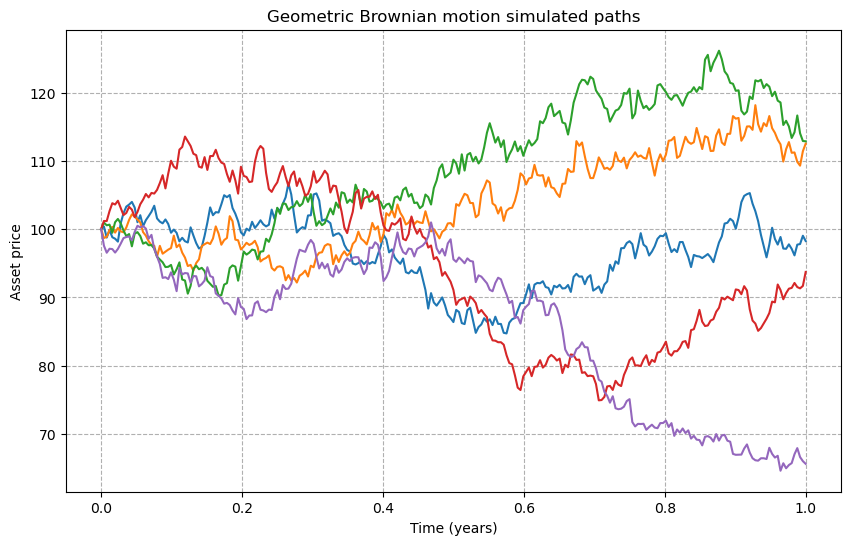

In [ ]:
# Plot GBM trajectories
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_paths = 5
t_grid = np.linspace(0.0, T, num_steps+1)
gbm_sims = generate_gbm(initial_price, interest_rate, volatility, time_horizon, num_steps, num_paths, rng_seed)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, gbm_sims)
plt.title(f"Geometric Brownian motion simulated paths")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.grid(ls="--")
plt.show()

## Determine Black-Scholes theoretical premium of European options
The premium of an option is the price at which the options contract is sold. 

### European call options
Call options give their owners the right, but not the obligation, to buy an underlying asset at a strike price $K$. European-style options can only be executed at maturity $T$. These definitions tell us that the fair price of an European call option at maturity is the expected payoff
$$C(t=T) = \mathbb{E}[\text{payoff}] = \mathbb{E}[\max(0, S_T-K)] \tag{5},$$
assuming no arbitrage. To calculate $C$, we define a variable $d$ that corresponds to zero payoff,
 $$K=S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}d\right] \tag{6},$$
and define $\phi$ and $\Phi$ as the probability and cumulative density functions of a standard normal random variable. Then the price of the call option at maturity is
$$\begin{align*}
C(t=T)&=\int_{S_T(d)}^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\cdot\phi(S_T)dS_T-\int_{K(d)}^\infty K\phi(K)dK \\
    &=\int_d^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\phi(z)dz-\int_d^\infty K\phi(z)dz \\
    &=S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T\right]\int_d^\infty \frac{1}{\sqrt{2\pi}}\exp\left[-\frac{1}{2}(z-\sigma\sqrt{T})^2+\frac{\sigma^2}{2} T\right]dz-K\Phi(-d) \\
    &=S_0 e^{\mu T}\int_{d-\sigma\sqrt{T}}^\infty \phi(u)du - K\Phi(-d) \\
    &=S_0 e^{\mu T}\Phi(-d+\sigma\sqrt{T})-K\Phi(-d) \\
    &=S_0 e^{\mu T}\Phi(d_1)-K\Phi(d_2) \tag{7}.
\end{align*}$$
with $d_1:=-d+\sigma\sqrt{T}$, and $d_2:=-d$.
Eq. (6) can be rearranged to 
$$d = \frac{\ln\frac{K}{S_0}-(\mu-\frac{\sigma^2}{2})T}{\sigma\sqrt{T}} \tag{8}$$
to give us
$$d_1=\frac{(\mu-\frac{\sigma^2}{2})T-\ln\frac{K}{S_0}}{\sigma\sqrt{T}}+\sigma\sqrt{T},$$
$$d_2=d_1-\sigma\sqrt{T} \tag{9}.$$
The price of the option at inception $t$ is the time-discounted price at maturity,
$$\begin{align*}
C(t=0)&=e^{-\mu T}C(t=T) \\
    &=S_0 \Phi(d_1)-Ke^{-\mu T}\Phi(d_2). \tag{10}
\end{align*}$$
### European put options
Put options give their owners the right, but not the obligation, to sell an underlying asset at a strike price $K$. By computing the put-call parity of European options, 
$$\begin{align*}
C(0)-P(0)&=e^{-\mu T}\mathbb{E}[S_T-K] \\
    &=e^{-\mu T}\left[\int_{-\infty}^\infty S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma\sqrt{T}z\right]\cdot\phi(S_T)dS_T-K\phi(K)dK\right] \\
    &=e^{-\mu T}(S_0 e^{\mu T}-K) \\
    &=S_0-K e^{-\mu T} \tag{11},
\end{align*}$$
we can easily obtain the fair price of an European put option,
$$\begin{align*}
P(t=0)&=S_0[\Phi(d_1)-1]+Ke^{-\mu T}[1-\Phi(d_2)] \\
    &=Ke^{-\mu T}\Phi(-d_2)-S_0\Phi(-d_1) \tag{12}.
\end{align*}$$

In [364]:
def black_scholes_premium(S0: float, mu: float, sigma: float, T: float, K: float, otype: str):
    '''
    Computes Black-Scholes premium of an European call or put option.

    Parameters
    ----------
    S0: Initial stock price
    mu: Mean or drift coefficient of asset
    sigma: Standard devidation or volatility coefficient of asset
    T: Lifespan of option in years
    K: Strike price
    otype: Type of option, 'call' or 'put'
    '''
    if otype != 'call' and otype != 'put': 
        print(f"{otype} is an invalid otype. Must be 'call' or 'put'.")
        return
    
    if T == 0: return 0

    d1 = ((mu - sigma**2 / 2) * T - np.log(K / S0)) / (sigma * np.sqrt(T)) + sigma * np.sqrt(T)
    d2 = d1 - sigma * np.sqrt(T)

    if otype == 'call':
        return S0 * norm.cdf(d1) - K * np.exp(-mu * T) * norm.cdf(d2)
    if otype == 'put':
        return K * np.exp(-mu * T) * norm.cdf(-d2)- S0 * norm.cdf(-d1)

In [ ]:
initial_price = 100.0
interest_rate = 0.05 # Risk-free interest rate
volatility = 0.2
time_horizon = 1 # 1 year
strike_price = 100.0

bs_call = black_scholes_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, 'call')
bs_put = black_scholes_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, 'put')

print(f"Black-Scholes European call option premium: {bs_call:.2f}")
print(f"Black-Scholes European put option premium: {bs_put:.2f}")

Black-Scholes European call option premium: 10.45
Black-Scholes European put option premium: 5.57


## Determine premiums from Monte Carlo simulations
Black-Scholes model provides a well-defined solution to the price of European options, but options where prices are path-dependent such as American options or some Asian options do not have a closed-form solution. Monte Carlo simulations can help us approximate the expected prices of these more complex options.



### Asian options
Like European options, Asian-style options can only be exercised at expiry. However, while the strike price of an European option is predetermined upon purchase, the strike price of an Asian option can be either determined by the average price over a time period before purchase in **average price options** or by the average price over a time period during the option's lifetime in **average strike options**.


In [ ]:
def monte_carlo_premium(S0: float, mu: float, sigma: float, T: float, K: float=None, n_steps: int=1, n_paths: int=1, seed=None, otype: str=None, to_plot=False):
    '''
    Generates Monte Carlo simulations of an option's price during its lifetime and computes the fair
    price at which the option contract should be exchanged. The price movements are assumed to follow
    Geometric Brownian Motion.

    Parameters
    ----------
    S0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of simulated paths to be generated
    otype: Type of option
        -'euc'/'eup': European call/put
        -'asc-p'/'asp-p': Average price call/put
        -'asc-s'/'asp-s': Average strike call/put
    seed: Random number generator seed, can be set for reproducibility
    to_plot: Whether a plot of Monte Carlo mean path and GBM drift path is to be plotted
    '''
    dt = T / n_steps
    discount_lifespan = np.exp(-mu * T)

    # Simulate Geometric Brownian Motion paths of asset prices
    # paths has shape (n_steps + 1, n_paths).
    paths = generate_gbm(S0, mu, sigma, T, n_steps, n_paths, seed)

    if otype == 'euc': 
        oname = 'European call option'
        payoffs = np.maximum(0, paths[-1,:] - K)

    elif otype == 'eup': 
        oname = 'European put option'
        payoffs = np.maximum(0, K - paths[-1,:])

    elif otype == 'asc-p': 
        oname = 'Average price call option'
        avg_prices = np.mean(paths, axis=0) # average of simulated prices over option lifespan
        payoffs = np.maximum(0, avg_prices - K)

    elif otype == 'asp-p': 
        oname = 'Average price put option'
        avg_prices = np.mean(paths, axis=0) 
        payoffs = np.maximum(0, K - avg_prices)

    elif otype == 'asc-s': 
        oname = 'Average strike call option'
        avg_prices = np.mean(paths, axis=0) 
        payoffs = np.maximum(0, avg_prices - paths[-1,:])

    elif otype == 'asp-s': 
        oname = 'Average strike put option'
        avg_prices = np.mean(paths, axis=0)
        payoffs = np.maximum(0, paths[-1,:] - avg_prices)

    else: 
        print(f'{otype} is an invalid otype.')
        return

    premiums = discount_lifespan * payoffs
    mcse = np.std(premiums) / np.sqrt(num_paths)

    if to_plot == True:
        t_grid = np.linspace(0.0, T, n_steps+1)
        plt.figure(figsize=(10, 6))
        plt.plot(t_grid, np.mean(paths, axis=1), color='k', label='Mean Monte Carlo path')
        plt.plot(t_grid, S0 * np.exp(mu * t_grid), color='r', ls='--', label='GBM drift path')
        plt.title(f"Monte Carlo simulation of {oname}")
        plt.xlabel("Time (years)")
        plt.ylabel("Asset price")
        plt.grid(ls="--")
        plt.legend()
        plt.show()
    
    return np.mean(premiums), mcse

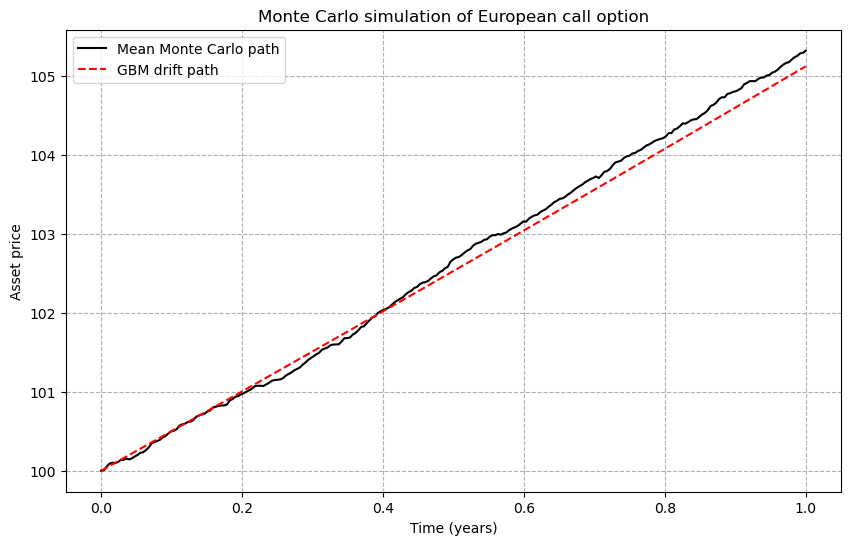

Monte Carlo European call option premium: 10.59 ± 0.148
Monte Carlo European put option premium: 5.53 ± 0.086


In [ ]:
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_paths = 10000
strike_price = 100.0

mc_eu_call, mcse_eu_call = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, rng_seed, 'euc', True)
mc_eu_put, mcse_eu_put = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, rng_seed, 'eup')

print(f"Monte Carlo European call option premium: {mc_eu_call:.2f} ± {mcse_eu_call:0.3f}")
print(f"Monte Carlo European put option premium: {mc_eu_put:.2f} ± {mcse_eu_put:0.3f}")

At a large number of Monte Carlo simulations `num_paths`, the mean price trajectory of the the simulations tends towards the path described by the deterministic $\mu S_t dt$ component of geometric Brownian motion Eq. (1), where the asset price $S_t$ grows exponentially with time $t$.

## Variance reduction of Monte Carlo simulations

### Antithetic variates
Antithetic variates make use of a symmetry in the normal distribution to reduce variance. If $Z$ is a sample randomly drawn from a standard normal distribution, then $-Z$ is another sample drawn from the same distribution. The payoff $X$ of an option in one path is computed from $Z$ through the function $f$. In the antithetic path, the resultant payoff $X'$ is computed from $-Z$ through the same function. Due to the input of $f$ in both paths coming from the same distribution,  $\mathbb{E}[X] = \mathbb{E}[X']$.

The antithetic estimator $\hat{X}$ is the average of each pair of original payoff $X$ and its antithetic complement $X'$,
$$\hat{X}=\frac{X+X'}{2}=\frac{f(Z)+f(-Z)}{2} \tag{13}.$$
The expected value of the estimator is equal to the expected value of the payoff of the option, 
\begin{align*}
\mathbb{E}[\hat{X}]&=\mathbb{E}\left[\frac{X+X'}{2}\right] \\
    &=\frac{\mathbb{E}[X]+\mathbb{E}[X']}{2} \\
    &=E[X] \tag{14},
\end{align*}
and the variance of the estimator satisfies
\begin{align*}
\text{Var}(\hat{X})&=\text{Var}\left(\frac{X+X'}{2}\right) \\
    &=\frac{1}{4}[\text{Var}(X)+\text{Var}(X')+2\text{Cov}(X,X')] \\
    &=\frac{1}{4}[\sigma_X^2+2\rho\sigma_X^2] \\
    &=\frac{\sigma_X^2}{2}(1+\rho) \tag{15}
\end{align*}
with $\sigma_X^2:=\text{Var}(X)=\text{Var}(X')$ and $\rho$ defined as the correlation between $X$ and $X'$. If $X$ and $X'$ were independent, we would get $\rho=0$, leading to $\text{Var}(\hat{X})=\frac{\sigma_X^2}{2}$. However, if the two samples were negatively correlated, we would have $\rho<1$, allowing us to obtain $\text{Var}(\hat{X})<\frac{\sigma_X^2}{2}$. The more negative the correlation, the larger the variance reduction. 

Strongly positive values of $Z$ results in high payoffs while strongly negative values of $Z$ result in low payoffs. The payoffs from $Z$ and $-Z$ move in opposite directions, causing $X$ and $X'$ to be negatively correlated. Thus the introduction of antithetic variates would reduce the variance of option payoffs and premiums.


In [410]:
def generate_gbm_redvar(S0: float, mu: float, sigma: float, T: float, n_steps, n_paths, seed=None):
    '''
    Generates a matrix of geometric brownian motion trajectories and their antithetic counterparts, with n_steps 
    rows and 2*n_paths columns. Antithetic trajectories are included to reduce variance.

    Parameters
    ----------
    S0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of simulated paths to be generated
    seed: Random number generator seed, can be set for reproducibility
    '''
    dt = T / n_steps
    rng = np.random.default_rng(seed)

    # Draw samples from standard normal distribution
    Z = rng.normal(0, 1, size=(n_steps, n_paths))

    # Multiplication factor per step
    step_factors = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    antithetic_step_factors = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * -Z)

    # Insert a row of 1s at the top to represent the t=0 state
    all_step_factors = np.vstack([np.ones((1, 2*n_paths)), np.hstack([step_factors, antithetic_step_factors])])

    # Cumulative product of asset prices
    paths = S0 * np.cumprod(all_step_factors, axis=0)

    return paths

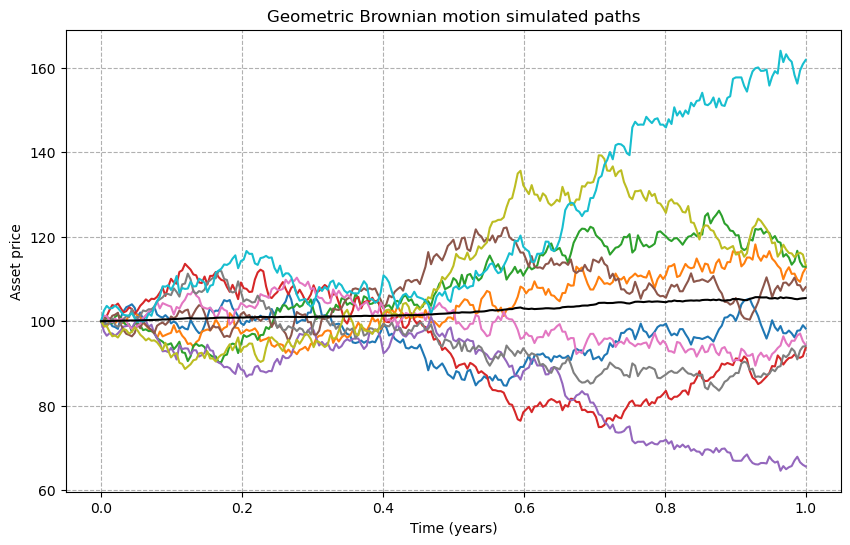

In [411]:
# Plot GBM trajectories
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_paths = 5
t_grid = np.linspace(0.0, time_horizon, num_steps+1)
gbm_sims_redvar = generate_gbm_redvar(initial_price, interest_rate, volatility, time_horizon, num_steps, num_paths, rng_seed)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, gbm_sims_redvar)
plt.plot(t_grid, np.mean(gbm_sims_redvar, axis=1), color='k')
plt.title(f"Geometric Brownian motion simulated paths")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.grid(ls="--")
plt.show()

In [ ]:
def monte_carlo_premium_redvar(S0: float, mu: float, sigma: float, T: float, K: float=None, n_steps: int=1, n_paths: int=1, otype: str=None, seed=None, to_plot=False):
    '''
    Generates Monte Carlo simulations of an option's price during its lifetime and computes the fair
    price at which the option contract should be exchanged. The price movements are assumed to follow
    Geometric Brownian Motion.

    Parameters
    ----------
    S0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of original paths to be simulated. Total number of paths simulated is 2*n_paths.
    otype: Type of option
        -'euc'/'eup': European call/put
        -'asc-p'/'asp-p': Asian average price call/put
        -'asc-s'/'asp-s': Asian average strike call/put
    seed: Random number generator seed, can be set for reproducibility
    '''
    dt = T / n_steps
    discount_step = np.exp(-mu * dt)
    discount_total = np.exp(-mu * T)

    # Simulate Geometric Brownian Motion paths of asset prices
    # paths has shape (n_steps + 1, 2*n_paths).
    paths = generate_gbm_redvar(S0, mu, sigma, T, n_steps, n_paths, seed)
    expiry_prices = paths[-1,:]

    if otype == 'euc': 
        og_payoffs = np.maximum(0, expiry_prices[:n_paths] - K)
        anti_payoffs = np.maximum(0, expiry_prices[n_paths:] - K)

    elif otype == 'eup': 
        og_payoffs = np.maximum(0, K - expiry_prices[:n_paths])
        anti_payoffs = np.maximum(0, K - expiry_prices[n_paths:])

    elif otype == 'asc-p': 
        og_avg_prices = np.mean(paths[:, :n_paths], axis=0) # average of simulated prices over option lifespan
        anti_avg_prices = np.mean(paths[:, n_paths:], axis=0)
        og_payoffs = np.maximum(0, og_avg_prices - K)
        anti_payoffs = np.maximum(0, anti_avg_prices - K)

    elif otype == 'asp-p': 
        og_avg_prices = np.mean(paths[:, :n_paths], axis=0)
        anti_avg_prices = np.mean(paths[:, n_paths:], axis=0)
        og_payoffs = np.maximum(0, K - og_avg_prices)
        anti_payoffs = np.maximum(0, K - anti_avg_prices)

    elif otype == 'asc-s': 
        og_avg_prices = np.mean(paths[:, :n_paths], axis=0) # average of simulated prices over option lifespan
        anti_avg_prices = np.mean(paths[:, n_paths:], axis=0)
        og_payoffs = np.maximum(0, og_avg_prices - expiry_prices[:n_paths])
        anti_payoffs = np.maximum(0, anti_avg_prices - expiry_prices[n_paths:])

    elif otype == 'asp-s': 
        og_avg_prices = np.mean(paths[:, :n_paths], axis=0) # average of simulated prices over option lifespan
        anti_avg_prices = np.mean(paths[:, n_paths:], axis=0)
        og_payoffs = np.maximum(0, expiry_prices[:n_paths] - og_avg_prices)
        anti_payoffs = np.maximum(0, expiry_prices[n_paths:] - anti_avg_prices)

    else: 
        print(f'{otype} is an invalid otype.')
        return
    
    antithetic_estimator_payoffs = (og_payoffs + anti_payoffs) / 2
    premiums = discount_total * antithetic_estimator_payoffs
    mcse = np.std(discount_total * antithetic_estimator_payoffs) / np.sqrt(2*n_paths)
    
    return np.mean(premiums), mcse

In [ ]:
# Variance reduction of European options
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_og_paths = int(10000 / 2)
strike_price = 100.0

mc_eu_call_redvar, mcse_eu_call_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, rng_seed, 'euc')
mc_eu_put_redvar, mcse_eu_put_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, rng_seed, 'eup')

print("Calculated using antithetic variates,")
print(f"Monte Carlo European call option premium: {mc_eu_call_redvar:.2f} ± {mcse_eu_call_redvar:0.3f}")
print(f"Monte Carlo European put option premium: {mc_eu_put_redvar:.2f} ± {mcse_eu_put_redvar:0.3f}")

Calculated using antithetic variates,
Monte Carlo European call option premium: 10.63 ± 0.074
Monte Carlo European put option premium: 5.69 ± 0.047


With $S_0=100, \mu=0.05, \sigma=0.2, T=1.0$, `num_steps` $= 252$, and $K = 100$, MCSE of 10,000 simulations of European call option premiums fell from 0.148 to 0.074. MCSE of the same number of simulations of European put option premiums fell from 0.086 to 0.047.

In [438]:
# Variance reduction of Asian options
mc_as_call_p, mcse_as_call_p = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, 'asc-p', rng_seed)
mc_as_put_p, mcse_as_put_p = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, 'asp-p', rng_seed)
mc_as_call_s, mcse_as_call_s = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, 'asc-p', rng_seed)
mc_as_put_s, mcse_as_put_s = monte_carlo_premium(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, 'asp-s', rng_seed)

mc_as_call_p_redvar, mcse_as_call_p_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, 'asc-p', rng_seed)
mc_as_put_p_redvar, mcse_as_put_p_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, 'asp-p', rng_seed)
mc_as_call_s_redvar, mcse_as_call_s_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, 'asc-p', rng_seed)
mc_as_put_s_redvar, mcse_as_put_s_redvar = monte_carlo_premium_redvar(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_og_paths, 'asp-s', rng_seed)

print("Change in Monte Carlo option premiums due to use of antithetic variates")
print(f"Asian average price call: {mc_as_call_p:.2f} ± {mcse_as_call_p:0.3f} -> {mc_as_call_p_redvar:.2f} ± {mcse_as_call_p_redvar:0.3f}")
print(f"Asian average price put: {mc_as_put_p:.2f} ± {mcse_as_put_p:0.3f} -> {mc_as_put_p_redvar:.2f} ± {mcse_as_put_p_redvar:0.3f}")
print(f"Asian average strike call: {mc_as_call_s:.2f} ± {mcse_as_call_s:0.3f} -> {mc_as_call_s_redvar:.2f} ± {mcse_as_call_s_redvar:0.3f}")
print(f"Asian average strike put: {mc_as_put_s:.2f} ± {mcse_as_put_s:0.3f} -> {mc_as_put_s_redvar:.2f} ± {mcse_as_put_s_redvar:0.3f}")

Change in Monte Carlo option premiums due to use of antithetic variates
Asian average price call: 5.81 ± 0.114 -> 5.84 ± 0.039
Asian average price put: 3.42 ± 0.075 -> 3.40 ± 0.029
Asian average strike call: 5.81 ± 0.114 -> 5.84 ± 0.039
Asian average strike put: 6.12 ± 0.124 -> 5.93 ± 0.044


## Greeks
The Greeks are quantities that characterise the sensitivity of a financial derivative product.

**Delta** ($\Delta$) measures the rate of change of the price of an option with respect to changes in the initial price of the underlying asset.
\begin{align*}
\Delta=\frac{\partial V}{\partial S_0}
\end{align*}
with $V=C(S_0, \mu, \sigma, T)$ representing the price of a call option or $V=P(S_0, \mu, \sigma, T)$ the price of a put option.

**Gamma** ($\Gamma$) measures the rate of change of $\Delta$ of an option with respect to changes in the initial price of the underlying asset.
\begin{align*}
\Gamma=\frac{\partial \Delta}{\partial S_0}=\frac{\partial^2 V}{\partial S_0^2}
\end{align*}

**Theta** ($\Theta$) measures the rate of change of price of an option with respect to the maturity period of the option.
\begin{align*}
\Theta=\frac{\partial V}{\partial T}
\end{align*}

**Vega** ($\nu$) measures of the rate of change of the price of an option with respect to changes in the volatility of the underlying asset.
\begin{align*}
\nu=\frac{\partial V}{\partial \sigma}
\end{align*}

**Rho** ($\rho$) measures the rate of change of the price of an option with respect to changes in the risk-free interest rate.
\begin{align*}
\rho=\frac{\partial V}{\partial \mu}
\end{align*}

### Black-Scholes model
Substituting the option price in Eq. (10) and Eq. (12) into the above definitions of the Greeks, we will get the following expressions that we can readily use for computing the Greeks of a Black-Scholes option at expiry,
$$\Delta_C=\Phi(d_1); \Delta_P = \Phi(d_1)-1;$$
$$\Gamma_{C,P}=\frac{\phi(d_1)}{S_0\sigma\sqrt{T}};$$
$$\Theta_C=\mu K \Phi(d_2)e^{-\mu T}+\frac{\sigma S_0\phi(d_1)}{2\sqrt{T}}; \Theta_P=-\mu K \Phi(-d_2)e^{-\mu T}+\frac{\sigma S_0 \phi(d_1)}{2\sqrt{T}}; \tag{13}$$
$$\nu_{C,P}=S_0\phi(d_1)\sqrt{T};$$
$$\rho_C=KT e^{-\mu T}\Phi(d_2); \rho_P=-KT e^{-\mu T}\Phi(-d_2).$$


In [11]:
def black_scholes_greeks(S0: float, mu: float, sigma: float, T: float, K: float, otype: str):
    '''
    Computes greeks of an European call or put option under the Black-Scholes model.

    Parameters
    ----------
    S0: Initial stock price
    mu: Mean or drift coefficient of asset
    sigma: Standard devidation or volatility coefficient of asset
    T: Lifespan of option in years
    K: Strike price
    otype: Type of option, 'call' or 'put'
    '''
    if otype != 'call' and otype != 'put': 
        print(f"{otype} is an invalid otype. Must be 'call' or 'put'.")
        return
    if T == 0: return 0

    d1 = ((mu - sigma**2 / 2) * T - np.log(K / S0)) / (sigma * np.sqrt(T)) + sigma * np.sqrt(T)
    d2 = d1 - sigma * np.sqrt(T)
    greeks = dict()

    if otype == 'call':
        greeks['Delta'] = norm.cdf(d1)
        greeks['Gamma'] = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
        greeks['Theta'] = mu * K * norm.cdf(d2) * np.exp(-mu * T) + (sigma * S0 * norm.pdf(d1)) / (2 * np.sqrt(T))
        greeks['Vega'] = S0 * norm.pdf(d1) * np.sqrt(T)
        greeks['Rho'] = K * T * np.exp(-mu * T) * norm.cdf(d2)

    if otype == 'put':
        greeks['Delta'] = norm.cdf(d1)-1
        greeks['Gamma'] = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
        greeks['Theta'] = - mu * K * norm.cdf(-d2) * np.exp(-mu * T) + (sigma * S0 * norm.pdf(d1)) / (2 * np.sqrt(T))
        greeks['Vega'] = S0 * norm.pdf(d1) * np.sqrt(T)
        greeks['Rho'] = -K * T * np.exp(-mu * T) * norm.cdf(-d2)
    return greeks


In [12]:
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
strike_price = 100.0

print('=== Greeks of Black-Scholes European call option ===')
for key, value in black_scholes_greeks(initial_price, interest_rate, volatility, time_horizon, strike_price, 'call').items():
    print(f'{key}: {value}')

=== Greeks of Black-Scholes European call option ===
Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Theta: 6.414027546438196
Vega: 37.52403469169379
Rho: 53.232481545376345


### Monte Carlo simulations
Partial derivatives over the discrete steps of Monte Carlo simulations can be approximated by finite difference methods. Specifically, we use the *central difference method* which combines the Taylor expansions of forward and backward differences, to make first-order approximations of the Greeks. The central difference approximation of the partial derivative of a function $g(x)$ at $x_i$, evaluated over grid points of uniform finite spacing $\Delta x$, is described by
$$\frac{\partial g(x_i)}{\partial x} \approx \frac{g(x_i+\Delta x)-g(x_i-\Delta x)}{2\Delta x} \tag{14}$$
up to the first order. For the second partial derivative of $g(x)$, its central difference approximation is given by
$$\frac{\partial^2 g(x_i)}{\partial x^2} \approx \frac{g(x_i + \Delta x)-2g(x_i)+g(x_i-\Delta x)}{(\Delta x)^2} \tag{15}$$
up to the first order.

<center>
<img src="Assets/finitedifference.png" width="500">
</center>

To compute $f(x_i+\Delta x)$ and $f(x_i-\Delta x)$, we will have to regenerate the Monte Carlo path simulations from the same random number generator seed that we utilised in computing $f(x_i)$. 

In [7]:
def monte_carlo_greeks(S0: float, mu: float, sigma: float, T: float, K: float, n_steps: int, n_paths: int, seed: int, otype: str=None):
    '''
    Computes greeks of Monte Carlo simulations of option prices. The price movements are assumed to follow
    Geometric Brownian Motion.

    Parameters
    ----------
    S0: Initial stock price
    mu: Drift coefficient of asset
    sigma: Volatility coefficient of asset
    T: Total duration of simulation in years
    n_steps: Number of time steps in the simulation
    n_paths: Number of simulated paths to be generated
    otype: Type of option
        -'euc'/'eup': European call/put
        -'asc-p'/'asp-p': Asian average price call/put
        -'asc-s'/'asp-s': Asian average strike call/put
    seed: Random number generator seed
    '''

    dt = T / n_steps
    discount_lifespan = np.exp(-mu * T)
    greeks = dict()

    # Simulate Geometric Brownian Motion paths of asset prices
    # paths has shape (n_steps + 1, n_paths).
    paths = generate_gbm(S0, mu, sigma, T, n_steps, n_paths, seed)

    def calc_payoffs(prices):
        if otype == 'euc': 
            return np.maximum(0, prices[-1,:] - K)

        elif otype == 'eup': 
            return np.maximum(0, K - prices[-1,:])

        elif otype == 'asc-p': 
            avg_prices = np.mean(prices, axis=0) # average of simulated prices over option lifespan
            return np.maximum(0, avg_prices - K)

        elif otype == 'asp-p': 
            avg_prices = np.mean(prices, axis=0) 
            return np.maximum(0, K - avg_prices)

        elif otype == 'asc-s': 
            avg_prices = np.mean(prices, axis=0) 
            return np.maximum(0, avg_prices - prices[-1,:])

        elif otype == 'asp-s': 
            avg_prices = np.mean(paths, axis=0)
            return np.maximum(0, prices[-1,:] - avg_prices)

    delta_S0 = 1E-2 # subject S0 to a small change
    paths_plus = generate_gbm(S0 + delta_S0, mu, sigma, T, n_steps, n_paths, seed)
    paths_minus = generate_gbm(S0 - delta_S0, mu, sigma, T, n_steps, n_paths, seed)
    V = np.mean(discount_lifespan * calc_payoffs(paths)) # get premiums like in black_scholes_greeks()
    V_plus = np.mean(discount_lifespan * calc_payoffs(paths_plus))
    V_minus = np.mean(discount_lifespan * calc_payoffs(paths_minus))
    greeks['Delta'] = (V_plus - V_minus) / (2 * delta_S0)
    greeks['Gamma'] = (V_plus - 2*V + V_minus) / (delta_S0**2)

    delta_T = 1E-2
    paths_plus = generate_gbm(S0, mu, sigma, T + delta_T, n_steps, n_paths, seed)
    paths_minus = generate_gbm(S0, mu, sigma, T - delta_T, n_steps, n_paths, seed)
    V_plus = np.mean(discount_lifespan * calc_payoffs(paths_plus))
    V_minus = np.mean(discount_lifespan * calc_payoffs(paths_minus))
    greeks['Theta'] = (V_plus - V_minus) / (2 * delta_T)

    delta_sigma = 1E-5
    paths_plus = generate_gbm(S0, mu, sigma + delta_sigma, T, n_steps, n_paths, seed)
    paths_minus = generate_gbm(S0, mu, sigma - delta_sigma, T, n_steps, n_paths, seed)
    V_plus = np.mean(discount_lifespan * calc_payoffs(paths_plus))
    V_minus = np.mean(discount_lifespan * calc_payoffs(paths_minus))    
    greeks['Vega'] = (V_plus - V_minus) / (2 * delta_sigma)

    delta_mu = 1E-5
    paths_plus = generate_gbm(S0, mu + delta_mu, sigma, T, n_steps, n_paths, seed)
    paths_minus = generate_gbm(S0, mu - delta_mu, sigma, T, n_steps, n_paths, seed)
    V_plus = np.mean(discount_lifespan * calc_payoffs(paths_plus))
    V_minus = np.mean(discount_lifespan * calc_payoffs(paths_minus))
    greeks['Rho'] = (V_plus - V_minus) / (2 * delta_mu)

    return greeks

In [13]:
initial_price = 100.0
interest_rate = 0.05
volatility = 0.2
time_horizon = 1.0 # 1 year
num_steps = 252 # Assume 252 trading days in a year
num_paths = 10000
strike_price = 100.0

print('=== Greeks of Monte Carlo European call option ===')
for key, value in monte_carlo_greeks(initial_price, interest_rate, volatility, time_horizon, strike_price, num_steps, num_paths, rng_seed, 'euc').items():
    print(f'{key}: {value}')

=== Greeks of Monte Carlo European call option ===
Delta: 0.6377567641311366
Gamma: 0.05324518022931102
Theta: 7.024684378604551
Vega: 38.35447275468695
Rho: 63.787537241211105


# References

[1] Glasserman, P. (2003). *Monte Carlo Methods in financial engineering*. Springer international publishing. 